# MMC PropagAtE vs sylph VHR

Compare PropagAtE and sylph phage:host ratios on MMC / no-MMC samples,
and sylph VHR induction (no-MMC vs MMC) within isolate pairs.

Host linking (**cascade**):
- species-level consensus (PHIST + CRISPR genomovar majority)
- **Cascade**: species co-detection → genus singleton → family singleton

**Cutoffs** (set in setup):
- `BREADTH_MIN` — CoverM `breadth_ratio` and PropagAtE `prophage_cov_breadth`
- `PHAGE_HOST_RATIO_MIN` — drop sylph VHRs below this
- `GENE_BREADTH_THRESHOLD` — gene-feature aggregation for the figure_s15 uninducible model
- `KMERS_REASSIGNED_MAX` — drop sylph detections where ≥ this fraction of genome k-mers were reassigned to a better-matching genome (k-mer conflict filter)


In [9]:
from pathlib import Path
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

try:
    from scipy.stats import spearmanr, pearsonr
except ImportError:
    spearmanr = pearsonr = None

BASE = Path('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB')
ANALYSIS = BASE / 'uhvdb-manuscript-update/mmc_activity_analysis'
REF_ANALYZE = ANALYSIS / 'results/uhvdb_toolkit/toolkit/referenceanalyze'
SYLPH_DIR = REF_ANALYZE / 'spring_sylph'
COVERM_DIR = REF_ANALYZE / 'spring_coverm'
GENECOVER_DIR = REF_ANALYZE / 'uhvdb_genecoverage'
GCP_DIR = ANALYSIS / 'results/genomad_checkv_propagate'
ANI_DIR = ANALYSIS / 'results/provirus_uhvdb_ani'
SYLPH_GENOME_ANI_DIR = ANALYSIS / 'results/sylph_detected_genome_ani'
METADATA_PATH = BASE / 'toolkit2/databases/uhvdb/5.0/uhvdb_metadata.tsv.gz'
MODEL_PATH = BASE / 'uhvdb-manuscript/figure_s15/phage_activity_model_full.joblib'
MODEL_META_PATH = BASE / 'uhvdb-manuscript/figure_s15/phage_model_metadata_full.joblib'

FIG1 = BASE / 'uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2'
PHIST_HOST = FIG1 / 'uhvdb_phisthost.tsv.gz'
CRISPR_HOST = FIG1 / 'uhvdb_crisprhost.tsv.gz'
SPECIES_INFO = FIG1 / 'uhvdb_species_info.tsv.gz'
GENOMOVAR_INFO = FIG1 / 'uhvdb_genomovars_info.tsv.gz'
GTDB_META = BASE / 'uhvdb-manuscript/figure_4/sylph_tax/gtdb_r214_metadata.tsv.gz'
SAMPLES_TSV = ANALYSIS / 'scripts/mvirs_samples.tsv'

BREADTH_MIN = 0.0
PHAGE_HOST_RATIO_MIN = 0.5
GENE_BREADTH_THRESHOLD = 0.8  # figure_s15 gene-feature aggregation
KMERS_REASSIGNED_MAX = 1.00  # drop sylph detections with >= 20% k-mers reassigned to a higher-ANI genome (~95% containment ANI)

profile_paths = sorted(SYLPH_DIR.glob('*.profile.tsv'))
print(f'Profiles: {len(profile_paths)} | BREADTH_MIN={BREADTH_MIN} | VHR_MIN={PHAGE_HOST_RATIO_MIN} | KMERS_REASSIGNED_MAX={KMERS_REASSIGNED_MAX}')
for label, path in [
    ('PHIST_HOST', PHIST_HOST), ('CRISPR_HOST', CRISPR_HOST),
    ('SPECIES_INFO', SPECIES_INFO), ('GENOMOVAR_INFO', GENOMOVAR_INFO),
    ('GTDB_META', GTDB_META), ('SAMPLES_TSV', SAMPLES_TSV),
    ('ANI_DIR', ANI_DIR), ('SYLPH_GENOME_ANI_DIR', SYLPH_GENOME_ANI_DIR),
    ('GENECOVER_DIR', GENECOVER_DIR), ('MODEL_PATH', MODEL_PATH),
]:
    print(f'{label} exists:', path.exists())


Profiles: 49 | BREADTH_MIN=0.0 | VHR_MIN=0.5 | KMERS_REASSIGNED_MAX=1.0
PHIST_HOST exists: True
CRISPR_HOST exists: True
SPECIES_INFO exists: True
GENOMOVAR_INFO exists: True
GTDB_META exists: True
SAMPLES_TSV exists: True
ANI_DIR exists: True
SYLPH_GENOME_ANI_DIR exists: True
GENECOVER_DIR exists: True
MODEL_PATH exists: True


## 1. Load sylph, CoverM, and host predictions

Viruses require CoverM `breadth_ratio ≥ BREADTH_MIN`. Hosts use PHIST+CRISPR genomovar-majority consensus keyed by species rep.


In [10]:
def sample_id_from_path(path: Path) -> str:
    name = path.name
    for suffix in ('.profile.tsv', '.depth.tsv', '.gene_coverage.tsv.gz', '.gene_coverage.tsv'):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return path.stem


def mmc_status_and_pair(sample_id: str):
    """Return (mmc_status, pair_id); normalize mmvirs_ -> mvirs_."""
    sid = re.sub(r'^mmvirs_', 'mvirs_', sample_id)
    if sid.endswith('_no_mmc'):
        return 'no_mmc', sid[: -len('_no_mmc')]
    if sid.endswith('_mmc'):
        return 'mmc', sid[: -len('_mmc')]
    return None, sid


def normalize_sample_id(sample_id: str) -> str:
    return re.sub(r'^mmvirs_', 'mvirs_', sample_id)


def load_coverm_depth(path: Path) -> pl.DataFrame:
    sample_id = sample_id_from_path(path)
    return (
        pl.read_csv(
            path, separator='\t', skip_rows=1, has_header=False,
            new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'],
        )
        .with_columns([
            pl.lit(sample_id).alias('sample_id'),
            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
        ])
        .with_columns((1 - np.e ** (-0.833 * pl.col('mean'))).alias('expected_breadth'))
        .with_columns([
            pl.when(pl.col('expected_breadth') > 1e-6)
            .then(pl.col('breadth') / pl.col('expected_breadth'))
            .otherwise(None)
            .alias('breadth_ratio'),
            pl.when(pl.col('trimmed_mean') > 0)
            .then(pl.col('variance') / pl.col('trimmed_mean'))
            .otherwise(None)
            .alias('variance_ratio'),
        ])
        .select(['sample_id', 'contig_id', 'breadth', 'breadth_ratio', 'variance_ratio'])
    )


profile_frames, empty_profiles = [], []
for path in profile_paths:
    df = pl.read_csv(path, separator='\t')
    sample_id = sample_id_from_path(path)
    if df.height == 0:
        empty_profiles.append(sample_id)
        continue
    status, pair_id = mmc_status_and_pair(sample_id)
    profile_frames.append(
        df.select([
            pl.lit(sample_id).alias('sample_id'),
            pl.lit(pair_id).alias('pair_id'),
            pl.lit(status).alias('mmc_status'),
            pl.col('Taxonomic_abundance').cast(pl.Float64),
            pl.col('Adjusted_ANI').cast(pl.Float64, strict=False).alias('ani'),
            pl.col('Contig_name').cast(pl.Utf8),
            pl.col('Genome_file').cast(pl.Utf8),
            pl.col('kmers_reassigned').cast(pl.Int64, strict=False),
            pl.col('Containment_ind').cast(pl.Utf8),
        ])
    )

profiles = pl.concat(profile_frames).with_columns(
    pl.col('Contig_name').str.starts_with('UHVDB-').alias('is_virus')
)
virus_rows_raw = profiles.filter(pl.col('is_virus'))
bac_rows = profiles.filter(~pl.col('is_virus'))

coverm = pl.concat([load_coverm_depth(p) for p in sorted(COVERM_DIR.glob('*.depth.tsv'))])
detected = (
    coverm
    .filter(pl.col('breadth_ratio') >= BREADTH_MIN)
    .select(['sample_id', pl.col('contig_id').alias('Contig_name'), 'breadth', 'breadth_ratio', 'variance_ratio'])
)
virus_rows = (
    virus_rows_raw
    .with_columns([
        pl.col('Containment_ind').str.split('/').list.get(1).cast(pl.Int64, strict=False).alias('containment_total'),
    ])
    .with_columns([
        (pl.col('kmers_reassigned') / pl.col('containment_total')).alias('kmers_reassigned_frac'),
    ])
    .filter(
        pl.col('kmers_reassigned_frac').is_null() | (pl.col('kmers_reassigned_frac') < KMERS_REASSIGNED_MAX)
    )
    .join(detected, on=['sample_id', 'Contig_name'], how='inner')
)

print(f'Nonempty profiles: {profiles["sample_id"].n_unique()} | empty: {len(empty_profiles)}')
print(
    f'Virus detections: {virus_rows_raw.height} -> {virus_rows.height} '
    f'after breadth_ratio>={BREADTH_MIN} and kmers_reassigned_frac<{KMERS_REASSIGNED_MAX}'
)


Nonempty profiles: 41 | empty: 8
Virus detections: 93 -> 93 after breadth_ratio>=0.0 and kmers_reassigned_frac<1.0


In [11]:
meta = (
    pl.read_csv(
        METADATA_PATH, separator='\t',
        columns=[
            'uhvdb_id', 'species_cluster_id', 'species_rep',
            'checkv_quality', 'virulent', 'aai_id', 'aai_af',
        ],
        infer_schema_length=10_000, ignore_errors=True,
    )
    .with_columns((pl.col('uhvdb_id') == pl.col('species_rep')).alias('is_species_rep'))
    .sort(['uhvdb_id', 'is_species_rep'], descending=[False, True])
    .unique(subset=['uhvdb_id'], keep='first')
)

uhvdb_genomovar_host = (
    pl.read_csv(PHIST_HOST, separator='\t')[
        ['uhvdb_id', 'total_connections', 'rank', 'agreement', 'consensus_taxonomy']
    ]
    .join(
        pl.read_csv(CRISPR_HOST, separator='\t')[
            ['uhvdb_id', 'total_connections', 'rank', 'agreement', 'top_taxonomy']
        ],
        on=['uhvdb_id', 'rank'],
        how='full',
        suffix='_crispr',
    )
    .fill_null(0)
    .with_columns(pl.col('consensus_taxonomy').str.replace(r'^(s|g|f)__', ''))
    .with_columns([
        pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy'))
        .then(pl.col('consensus_taxonomy'))
        .when(
            (pl.col('total_connections') * pl.col('agreement'))
            >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))
        )
        .then(pl.col('consensus_taxonomy'))
        .otherwise(pl.col('top_taxonomy'))
        .alias('final_taxonomy'),
        pl.when(pl.col('rank').is_not_null()).then(pl.col('rank')).otherwise(pl.col('rank_crispr')).alias('final_rank'),
        pl.when(pl.col('uhvdb_id').is_not_null()).then(pl.col('uhvdb_id')).otherwise(pl.col('uhvdb_id_crispr')).alias('final_id'),
    ])
    .group_by('final_id')
    .agg([
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'species').first().alias('final_species'),
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'genus').first().alias('final_genus'),
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'family').first().alias('final_family'),
    ])
    .rename({'final_id': 'uhvdb_id'})
)

species_info = pl.read_csv(SPECIES_INFO, separator='\t').select([
    'uhvdb_id',
    pl.col('cluster_id').alias('species_cluster_id'),
    pl.col('votu_rep').alias('species_rep'),
])
genomovar_reps = (
    pl.read_csv(GENOMOVAR_INFO, separator='\t')
    .filter(pl.col('uhvdb_id') == pl.col('votu_rep'))
    .select(pl.col('uhvdb_id').alias('genomovar_rep'))
    .unique()
)
gv_in_species = (
    species_info
    .join(genomovar_reps, left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
    .join(uhvdb_genomovar_host, on='uhvdb_id', how='left')
    .rename({'uhvdb_id': 'genomovar_rep'})
)


def majority_host(df: pl.DataFrame, col: str) -> pl.DataFrame:
    return (
        df
        .filter(pl.col(col).is_not_null())
        .group_by(['species_cluster_id', col])
        .agg(pl.len().alias('n'))
        .sort(['species_cluster_id', 'n', col], descending=[False, True, False])
        .unique('species_cluster_id', maintain_order=True)
        .select(['species_cluster_id', col])
    )


uhvdb_combinedhost = (
    species_info
    .select(['species_cluster_id', 'species_rep'])
    .unique()
    .join(majority_host(gv_in_species, 'final_species'), on='species_cluster_id', how='left')
    .join(majority_host(gv_in_species, 'final_genus'), on='species_cluster_id', how='left')
    .join(majority_host(gv_in_species, 'final_family'), on='species_cluster_id', how='left')
    .select([
        pl.col('species_rep').alias('uhvdb_id'),
        'final_species',
        'final_genus',
        'final_family',
    ])
)

viruses = (
    virus_rows
    .join(meta, left_on='Contig_name', right_on='uhvdb_id', how='left')
    .join(
        uhvdb_combinedhost.select(['uhvdb_id', 'final_species', 'final_genus', 'final_family']),
        left_on='Contig_name',
        right_on='uhvdb_id',
        how='left',
    )
    .select([
        'sample_id', 'pair_id', 'mmc_status', 'Contig_name',
        'Taxonomic_abundance', 'ani', 'breadth', 'breadth_ratio', 'variance_ratio',
        'species_cluster_id', 'final_species',
        pl.col('final_genus').alias('host_genus'),
        pl.col('final_family').alias('host_family'),
        'checkv_quality', 'virulent', 'aai_id', 'aai_af',
    ])
    .rename({'Taxonomic_abundance': 'virus_tax_abund'})
)

print(
    f'Virus rows with metadata: '
    f'{viruses.filter(pl.col("species_cluster_id").is_not_null()).height}/{viruses.height}'
)
print(
    'with host species:', viruses.filter(pl.col('final_species').is_not_null()).height,
    '| with host genus:', viruses.filter(pl.col('host_genus').is_not_null()).height,
    '| with host family:', viruses.filter(pl.col('host_family').is_not_null()).height,
)


Virus rows with metadata: 93/93
with host species: 83 | with host genus: 85 | with host family: 87


## 2. Sylph phage-to-host ratio (VHR)

**Cascade** primary PTH:

1. Predicted host **species** co-detected
2. Else **genus singleton**: exactly one co-detected species in the predicted host genus
3. Else **family singleton**: exactly one co-detected species in the predicted host family

Keep only virus **species** (`species_cluster_id`) detected in **both** MMC and no-MMC within each isolate pair.


In [12]:
gtdb_meta = (
    pl.read_csv(GTDB_META, separator='\t', has_header=False, new_columns=['accession', 'lineage'])
    .with_columns([
        pl.col('lineage').str.extract(r'f__([^;]+)', 1).alias('family'),
        pl.col('lineage').str.extract(r'g__([^;]+)', 1).alias('genus'),
        pl.col('lineage').str.extract(r's__([^;]+)', 1).alias('species'),
    ])
    .unique('accession')
)

bac_sylph = (
    bac_rows
    .with_columns(pl.col('Genome_file').str.extract(r'(GC[AF]_\d+\.\d+)', 1).alias('accession'))
    .join(gtdb_meta, on='accession', how='left')
    .filter(pl.col('species').is_not_null())
    .group_by(['sample_id', 'species', 'genus', 'family'])
    .agg(pl.col('Taxonomic_abundance').max().alias('host_tax_abund'))
)

# Reference-assembly host species from mvirs_samples.tsv (GCA↔GCF GTDB match)
# — used for oligo isolate coloring / pair legend labels, not for VHR filtering.
gtdb_acc = gtdb_meta.with_columns(
    pl.col('accession').str.replace(r'^(RS_|GB_)', '').alias('ref_accession')
)
gtdb_swapped = gtdb_acc.with_columns(
    pl.when(pl.col('ref_accession').str.starts_with('GCA_'))
    .then(pl.col('ref_accession').str.replace(r'^GCA_', 'GCF_'))
    .when(pl.col('ref_accession').str.starts_with('GCF_'))
    .then(pl.col('ref_accession').str.replace(r'^GCF_', 'GCA_'))
    .otherwise(pl.col('ref_accession'))
    .alias('ref_accession')
)
gtdb_lookup = (
    pl.concat([
        gtdb_acc.select(['ref_accession', 'species', 'genus']),
        gtdb_swapped.select(['ref_accession', 'species', 'genus']),
    ])
    .unique('ref_accession', keep='first')
)

ref_host = (
    pl.read_csv(SAMPLES_TSV, separator='\t')
    .rename({'sample': 'sample_id'})
    .with_columns(pl.col('fna').str.extract(r'(GC[AF]_\d+\.\d+)', 1).alias('ref_accession'))
    .join(gtdb_lookup, on='ref_accession', how='left')
    .select(['sample_id', 'ref_accession', 'species', 'genus'])
    .rename({'species': 'ref_species', 'genus': 'ref_genus'})
)

phage_with_host = viruses.select([
    'sample_id', 'pair_id', 'mmc_status', 'Contig_name', 'species_cluster_id',
    'virus_tax_abund', 'final_species', 'host_genus', 'host_family',
])

# ---------------------------------------------------------------------------
# Cascade: species_codetected → genus_singleton → family_singleton
# ---------------------------------------------------------------------------
species_hits = (
    phage_with_host
    .filter(pl.col('final_species').is_not_null() & (pl.col('virus_tax_abund') > 0))
    .join(
        bac_sylph.select(['sample_id', 'species', 'host_tax_abund']),
        left_on=['sample_id', 'final_species'],
        right_on=['sample_id', 'species'],
        how='inner',
    )
    .with_columns([
        pl.lit('species_codetected').alias('host_match_method'),
        pl.col('final_species').alias('matched_host_species'),
    ])
)
matched_keys = species_hits.select(['sample_id', 'Contig_name']).unique()

genus_singleton = (
    bac_sylph
    .filter(pl.col('genus').is_not_null())
    .group_by(['sample_id', 'genus'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('species').first().alias('species'),
        pl.col('host_tax_abund').first().alias('host_tax_abund'),
    ])
    .filter(pl.col('n_species') == 1)
)
genus_hits = (
    phage_with_host
    .join(matched_keys, on=['sample_id', 'Contig_name'], how='anti')
    .filter(pl.col('host_genus').is_not_null() & (pl.col('virus_tax_abund') > 0))
    .join(
        genus_singleton.select(['sample_id', 'genus', 'species', 'host_tax_abund']),
        left_on=['sample_id', 'host_genus'],
        right_on=['sample_id', 'genus'],
        how='inner',
    )
    .with_columns([
        pl.lit('genus_singleton').alias('host_match_method'),
        pl.col('species').alias('matched_host_species'),
    ])
)
matched_keys = pl.concat([
    matched_keys,
    genus_hits.select(['sample_id', 'Contig_name']),
]).unique()

family_singleton = (
    bac_sylph
    .filter(pl.col('family').is_not_null())
    .group_by(['sample_id', 'family'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('species').first().alias('species'),
        pl.col('host_tax_abund').first().alias('host_tax_abund'),
    ])
    .filter(pl.col('n_species') == 1)
)
family_hits = (
    phage_with_host
    .join(matched_keys, on=['sample_id', 'Contig_name'], how='anti')
    .filter(pl.col('host_family').is_not_null() & (pl.col('virus_tax_abund') > 0))
    .join(
        family_singleton.select(['sample_id', 'family', 'species', 'host_tax_abund']),
        left_on=['sample_id', 'host_family'],
        right_on=['sample_id', 'family'],
        how='inner',
    )
    .with_columns([
        pl.lit('family_singleton').alias('host_match_method'),
        pl.col('species').alias('matched_host_species'),
    ])
)

vhr_cols = [
    'sample_id', 'pair_id', 'mmc_status', 'Contig_name', 'species_cluster_id',
    'virus_tax_abund', 'host_tax_abund', 'final_species', 'host_genus', 'host_family',
    'matched_host_species', 'host_match_method',
]
vhr_cascade = (
    pl.concat([
        species_hits.select(vhr_cols),
        genus_hits.select(vhr_cols),
        family_hits.select(vhr_cols),
    ])
    .with_columns((pl.col('virus_tax_abund') / pl.col('host_tax_abund')).alias('phage_host_ratio'))
    .filter(pl.col('host_tax_abund') > 0)
    .unique(subset=['sample_id', 'Contig_name'], keep='first')
)
print('Cascade VHR rows:', vhr_cascade.height)
print(vhr_cascade.group_by('host_match_method').len().sort('host_match_method'))

# Primary VHR = cascade only
vhr = (
    vhr_cascade
    .filter(pl.col('species_cluster_id').is_not_null())
    .sort(['sample_id', 'species_cluster_id', 'virus_tax_abund'], descending=[False, False, True])
    .unique(subset=['sample_id', 'species_cluster_id'], keep='first')
)
n_before = vhr.height
vhr = vhr.filter(pl.col('phage_host_ratio') >= PHAGE_HOST_RATIO_MIN)
print(f'VHR species rows: {n_before} -> {vhr.height} after phage_host_ratio>={PHAGE_HOST_RATIO_MIN}')
print(vhr.group_by('host_match_method').len().sort('host_match_method'))

# Keep only species detected in both MMC and no-MMC within each isolate pair
n_before_pair = vhr.height
paired_species = (
    vhr
    .group_by(['pair_id', 'species_cluster_id'])
    .agg(pl.col('mmc_status').n_unique().alias('n_status'))
    .filter(pl.col('n_status') == 2)
    .select(['pair_id', 'species_cluster_id'])
)
vhr = vhr.join(paired_species, on=['pair_id', 'species_cluster_id'], how='inner')
print(
    f'Require species in both MMC and no-MMC within pair: {n_before_pair} -> {vhr.height} '
    f'({paired_species.height} species × pair)'
)


Cascade VHR rows: 80
shape: (3, 2)
┌────────────────────┬─────┐
│ host_match_method  ┆ len │
│ ---                ┆ --- │
│ str                ┆ u32 │
╞════════════════════╪═════╡
│ family_singleton   ┆ 4   │
│ genus_singleton    ┆ 1   │
│ species_codetected ┆ 75  │
└────────────────────┴─────┘
Closest-to-1 VHR rows: 76
Union(min) VHR rows: 80
shape: (2, 2)
┌───────────────────┬─────┐
│ host_match_method ┆ len │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ cascade_only      ┆ 4   │
│ min_closest       ┆ 76  │
└───────────────────┴─────┘
VHR species rows: 80 -> 79 after phage_host_ratio>=0.5
shape: (2, 2)
┌───────────────────┬─────┐
│ host_match_method ┆ len │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ cascade_only      ┆ 4   │
│ min_closest       ┆ 75  │
└───────────────────┴─────┘
Require species in both MMC and no-MMC within pair: 79 -> 60 (30 species × pair)


## 3. VHR: no-MMC vs MMC

Sylph detections with ≥ `KMERS_REASSIGNED_MAX` fraction of genome k-mers reassigned to a higher-ANI genome are removed upstream (k-mer conflict filter in §1).

Paired VHRs within each isolate across MMC status:
- **Sylph:** `pair_id` + `uhvdb_id`
- **PropagAtE:** `pair_id` + prophage `fragment` (same chromosomal locus), `prophage_cov_breadth ≥ BREADTH_MIN`

Boxplots by MMC status; lines connect the same virus/locus across conditions (color = isolate).


Sylph VHR after k-mer conflict filter (kmers_reassigned_frac<1.0): 60 detections
Sylph pairing (after derep): shape: (1, 2)
┌────────────┬───────┐
│ point_type ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ both       ┆ 30    │
└────────────┴───────┘
Sylph paired clusters: 30 across 7 isolates
PropagAtE pairing: shape: (1, 2)
┌────────────┬───────┐
│ point_type ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ both       ┆ 77    │
└────────────┴───────┘
PropagAtE paired loci: 44 across 12 isolates


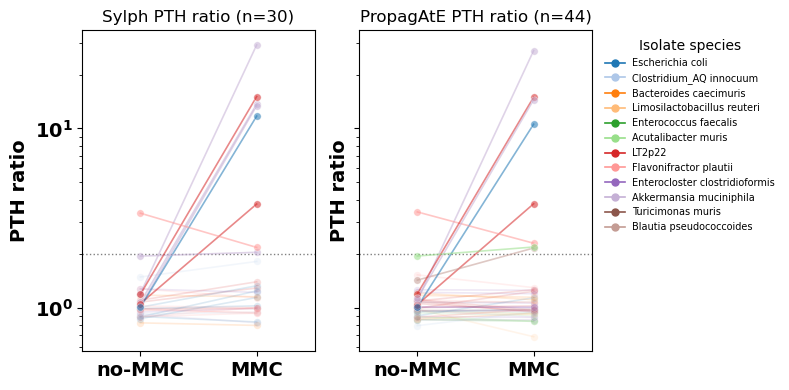

Top sylph fold-changes:
shape: (6, 5)
┌──────────────┬──────────────┬────────────┬───────────┬─────────────────┐
│ pair_id      ┆ uhvdb_id     ┆ vhr_no_mmc ┆ vhr_mmc   ┆ mmc_fold_change │
│ ---          ┆ ---          ┆ ---        ┆ ---       ┆ ---             │
│ str          ┆ str          ┆ f64        ┆ f64       ┆ f64             │
╞══════════════╪══════════════╪════════════╪═══════════╪═════════════════╡
│ mvirs_YL44   ┆ UHVDB-203376 ┆ 1.198115   ┆ 29.262598 ┆ 24.423874       │
│ mvirs_YL44   ┆ UHVDB-171903 ┆ 1.016512   ┆ 13.401602 ┆ 13.183906       │
│ mvirs_YL44   ┆ UHVDB-211730 ┆ 1.0684     ┆ 13.687317 ┆ 12.811044       │
│ mvirs_LT2p22 ┆ UHVDB-302070 ┆ 1.185429   ┆ 15.071333 ┆ 12.713816       │
│ mvirs_HS     ┆ UHVDB-295091 ┆ 1.004901   ┆ 11.723035 ┆ 11.665864       │
│ mvirs_LT2p22 ┆ UHVDB-305727 ┆ 1.052981   ┆ 3.785696  ┆ 3.595218        │
└──────────────┴──────────────┴────────────┴───────────┴─────────────────┘
Top PropagAtE fold-changes:
shape: (6, 5)
┌──────────────┬────

In [13]:
sylph_vhr_all = (
    vhr.select([
        'sample_id', 'pair_id', 'mmc_status', 'species_cluster_id', 'Contig_name',
        'matched_host_species', 'phage_host_ratio',
    ])
    .rename({'phage_host_ratio': 'sylph_phage_host_ratio', 'Contig_name': 'uhvdb_id'})
    .join(
        viruses.select(['sample_id', 'Contig_name', 'ani'])
        .rename({'Contig_name': 'uhvdb_id', 'ani': 'sylph_ani'}),
        on=['sample_id', 'uhvdb_id'],
        how='left',
    )
    .with_columns(pl.col('sample_id').map_elements(normalize_sample_id, return_dtype=pl.Utf8).alias('sample_id_norm'))
)

# k-mer conflict filter already applied upstream (kmers_reassigned_frac < KMERS_REASSIGNED_MAX);
# each remaining detection is already its own representative
vhr_derep = sylph_vhr_all.unique(subset=['sample_id_norm', 'uhvdb_id'], maintain_order=True)
print(
    f'Sylph VHR after k-mer conflict filter '
    f'(kmers_reassigned_frac<{KMERS_REASSIGNED_MAX}): {vhr_derep.height} detections'
)

# --- Sylph: pair UHVDBs across MMC ---
vhr_mmc_pair = (
    vhr_derep
    .group_by(['pair_id', 'uhvdb_id'])
    .agg([
        pl.col('sylph_phage_host_ratio').filter(pl.col('mmc_status') == 'no_mmc').first().alias('vhr_no_mmc'),
        pl.col('sylph_phage_host_ratio').filter(pl.col('mmc_status') == 'mmc').first().alias('vhr_mmc'),
        pl.col('matched_host_species').drop_nulls().first().alias('matched_host_species'),
    ])
    .with_columns([
        pl.when(pl.col('vhr_no_mmc').is_not_null() & pl.col('vhr_mmc').is_not_null()).then(pl.lit('both'))
        .when(pl.col('vhr_no_mmc').is_not_null()).then(pl.lit('no_mmc_only'))
        .otherwise(pl.lit('mmc_only'))
        .alias('point_type'),
    ])
    .with_columns(
        pl.when(pl.col('point_type') == 'both')
        .then(pl.col('vhr_mmc') / pl.col('vhr_no_mmc'))
        .otherwise(None)
        .alias('mmc_fold_change')
    )
)
both_sylph_mmc = vhr_mmc_pair.filter(pl.col('point_type') == 'both')

# --- PropagAtE: pair loci across MMC ---
prop_mmc_rows = []
for tsv in sorted(GCP_DIR.glob('*/propagate/*.propagate.tsv')):
    sample = tsv.parent.parent.name
    try:
        df = pl.read_csv(tsv, separator='\t')
    except Exception:
        continue
    if df.height == 0 or 'prophage' not in df.columns or 'prophage-host_ratio' not in df.columns:
        continue
    status, pair_id = mmc_status_and_pair(sample)
    if status is None:
        continue
    prop_mmc_rows.append(
        df.with_columns([
            pl.lit(normalize_sample_id(sample)).alias('sample_id'),
            pl.lit(status).alias('mmc_status'),
            pl.lit(pair_id).alias('pair_id'),
        ])
        .rename({'prophage': 'fragment', 'prophage-host_ratio': 'propagate_phage_host_ratio'})
        .select([
            'sample_id', 'pair_id', 'mmc_status', 'fragment',
            'propagate_phage_host_ratio', 'prophage_cov_breadth',
        ])
    )
prop_for_mmc = (
    pl.concat(prop_mmc_rows, how='diagonal_relaxed')
    .filter(pl.col('prophage_cov_breadth') >= 0.5)
    if prop_mmc_rows else pl.DataFrame()
)
prop_mmc_pair = (
    prop_for_mmc
    .group_by(['pair_id', 'fragment'])
    .agg([
        pl.col('propagate_phage_host_ratio').filter(pl.col('mmc_status') == 'no_mmc').first().alias('vhr_no_mmc'),
        pl.col('propagate_phage_host_ratio').filter(pl.col('mmc_status') == 'mmc').first().alias('vhr_mmc'),
    ])
    .with_columns([
        pl.when(pl.col('vhr_no_mmc').is_not_null() & pl.col('vhr_mmc').is_not_null()).then(pl.lit('both'))
        .when(pl.col('vhr_no_mmc').is_not_null()).then(pl.lit('no_mmc_only'))
        .otherwise(pl.lit('mmc_only'))
        .alias('point_type'),
    ])
    .with_columns(
        pl.when(pl.col('point_type') == 'both')
        .then(pl.col('vhr_mmc') / pl.col('vhr_no_mmc'))
        .otherwise(None)
        .alias('mmc_fold_change')
    )
)
both_prop_mmc = prop_mmc_pair.filter(pl.col('point_type') == 'both').filter(pl.col('pair_id') != 'mvirs_oligo_fecal')

print('Sylph pairing (after derep):', vhr_mmc_pair['point_type'].value_counts())
print(
    f'Sylph paired clusters: {both_sylph_mmc.height} across '
    f'{both_sylph_mmc["pair_id"].n_unique()} isolates'
)
print('PropagAtE pairing:', prop_mmc_pair['point_type'].value_counts())
print(
    f'PropagAtE paired loci: {both_prop_mmc.height} across '
    f'{both_prop_mmc["pair_id"].n_unique()} isolates'
)

pair_ids = sorted(set(both_sylph_mmc['pair_id'].unique().to_list()) | set(both_prop_mmc['pair_id'].unique().to_list()))
cmap = plt.get_cmap('tab20')
pair_colors = {pid: cmap(i % 20) for i, pid in enumerate(pair_ids)}

# pair_id → reference-assembly host species for legend labels
pair_species_map = dict(
    ref_host
    .with_columns(
        pl.col('sample_id')
        .map_elements(lambda s: mmc_status_and_pair(s)[1], return_dtype=pl.Utf8)
        .alias('pair_id')
    )
    .group_by('pair_id')
    .agg(pl.col('ref_species').drop_nulls().first().alias('species'))
    .iter_rows()
)


def paired_mmc_boxplot(ax, paired_df, title, ylabel):
    if paired_df.height == 0:
        ax.set_title(title + ' (none)')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['no-MMC', 'MMC'], fontsize=14, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
        ax.tick_params(axis='both', labelsize=14)
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')
        return
    # ax.boxplot(
    #     [paired_df['vhr_no_mmc'].to_list(), paired_df['vhr_mmc'].to_list()],
    #     positions=[0, 1], widths=0.45, patch_artist=True,
    #     showfliers=False, zorder=1,
    #     medianprops=dict(color='black', lw=1.5),
    #     whiskerprops=dict(color='0.4'),
    #     capprops=dict(color='0.4'),
    #     boxprops=dict(facecolor='0.92', edgecolor='0.4', alpha=0.9),
    # )
    rng = np.random.default_rng(0)
    for row in paired_df.iter_rows(named=True):
        color = pair_colors[row['pair_id']]
        j = float(rng.uniform(-0.00, 0.00))
        xs = [0 + j, 1 + j]
        ys = [row['vhr_no_mmc'], row['vhr_mmc']]
        # Fade viruses that never reach VHR >= 2 in either condition
        crosses_vhr2 = max(ys) >= 2
        alpha = 0.55 if crosses_vhr2 else 0.15
        z = 3 if crosses_vhr2 else 1
        ax.plot(xs, ys, color=color, alpha=alpha, lw=1.2, zorder=z)
        ax.scatter(xs, ys, color=color, s=28, alpha=alpha, zorder=z + 1,
                   edgecolors='white', linewidths=0.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['no-MMC', 'MMC'], fontsize=14, fontweight='bold')
    ax.set_xlim(-0.5, 1.5)
    ax.set_yscale('log')
    ax.axhline(2, color='gray', ls=':', lw=1, zorder=0)
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(f'{title} (n={paired_df.height})')
    ax.tick_params(axis='both', labelsize=14)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')


fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
paired_mmc_boxplot(axes[0], both_sylph_mmc, 'Sylph PTH ratio', 'PTH ratio')
paired_mmc_boxplot(axes[1], both_prop_mmc, 'PropagAtE PTH ratio', 'PTH ratio')

handles = [
    plt.Line2D(
        [0], [0], color=pair_colors[pid], marker='o', lw=1.2, markersize=5,
        label=pair_species_map.get(pid) or pid.replace('mvirs_', '').replace('transduct_', 'td_'),
    )
    for pid in pair_ids
]
axes[1].legend(
    handles=handles, frameon=False, fontsize=7, title='Isolate species',
    loc='upper left', bbox_to_anchor=(1.02, 1.0),
)
fig.tight_layout()
plt.show()

both_mmc = both_sylph_mmc

print('Top sylph fold-changes:')
print(
    both_sylph_mmc
    .select(['pair_id', 'uhvdb_id', 'vhr_no_mmc', 'vhr_mmc', 'mmc_fold_change'])
    .sort('mmc_fold_change', descending=True)
    .head(6)
)
print('Top PropagAtE fold-changes:')
print(
    both_prop_mmc
    .select(['pair_id', 'fragment', 'vhr_no_mmc', 'vhr_mmc', 'mmc_fold_change'])
    .sort('mmc_fold_change', descending=True)
    .head(6)
)


## 4. PropagAtE vs sylph VHR

Sylph detections with ≥ `KMERS_REASSIGNED_MAX` fraction of genome k-mers reassigned to a higher-ANI genome are removed upstream (k-mer conflict filter in §1).

Link PropagAtE loci via **strict RBH** to the filtered sylph detections (`match_q` / `match_t`).

Scatter shows **RBH pairs only** (linear axes). One-sided detections are omitted from the scatter but still used in the CheckV panel below. Only samples with PropagAtE output are kept; **oligo fecal** samples are excluded. Points are colored by MMC status.

Bottom panel: **CheckV completeness** of PropagAtE proviruses that are `propagate_only` vs those with a sylph RBH partner (`both`), counting each **isolate × virus species** once (MMC/no-MMC not double-counted).

Requires `results/provirus_uhvdb_ani/` and `results/sylph_detected_genome_ani/`.


In [14]:
TOP_HITS_PATH = ANI_DIR / 'proviruses_vs_uhvdb.top_hits.tsv'
ANICALC_PATH = ANI_DIR / 'proviruses_vs_uhvdb.anicalc.tsv'
if not TOP_HITS_PATH.exists():
    raise FileNotFoundError(f'Missing {TOP_HITS_PATH}')

top_hits = (
    pl.read_csv(TOP_HITS_PATH, separator='\t')
    .with_columns([
        pl.col('species_cluster_id').cast(pl.Int64, strict=False),
        pl.col('global_ani').cast(pl.Float64),
        pl.col('tani').cast(pl.Float64),
        pl.col('pid').cast(pl.Float64),
        pl.col('qcov').cast(pl.Float64),
    ])
)

prop_rows = []
for tsv in sorted(GCP_DIR.glob('*/propagate/*.propagate.tsv')):
    sample = tsv.parent.parent.name
    try:
        df = pl.read_csv(tsv, separator='\t')
    except Exception:
        continue
    if df.height == 0 or 'prophage' not in df.columns or 'prophage-host_ratio' not in df.columns:
        continue
    prop_rows.append(
        df.with_columns(pl.lit(sample).alias('sample_id'))
        .rename({'prophage': 'fragment', 'prophage-host_ratio': 'propagate_phage_host_ratio'})
        .select([
            'sample_id', 'fragment', 'host', 'active', 'CohenD',
            'propagate_phage_host_ratio', 'prophage_mean_cov', 'host_mean_cov', 'prophage_cov_breadth',
        ])
    )
propagate_raw = pl.concat(prop_rows, how='diagonal_relaxed') if prop_rows else pl.DataFrame()
propagate = propagate_raw.filter(pl.col('prophage_cov_breadth') >= BREADTH_MIN)
print(
    f'PropagAtE breadth filter (>={BREADTH_MIN:.0%}): '
    f'{propagate.height}/{propagate_raw.height} kept'
)

prop_mapped = (
    propagate.join(top_hits, on=['sample_id', 'fragment'], how='inner')
    .filter(pl.col('species_cluster_id').is_not_null())
    .sort(['sample_id', 'species_cluster_id', 'tani'], descending=[False, False, True])
    .unique(subset=['sample_id', 'species_cluster_id'], keep='first')
)
print(f'Mapped to species: {prop_mapped.height} | tANI median: {top_hits["tani"].median():.2f}')


PropagAtE breadth filter (>=0%): 180/180 kept
Mapped to species: 176 | tANI median: 41.44


Restrict to samples with PropagAtE output: 24 samples; sylph VHR 60 -> 60
Sylph VHR after k-mer conflict filter (kmers_reassigned_frac<1.0): 60 detections
CheckV completeness assigned: 88/90 PropagAtE loci
ANI hits (sylph-detected UHVDBs): 70 | RBH pairs: 38
PropagAtE <-> sylph VHR (derep): 112 (both/RBH=38, sylph_only=22, propagate_only=52)
shape: (6, 3)
┌────────────┬────────────────┬─────┐
│ mmc_status ┆ point_type     ┆ len │
│ ---        ┆ ---            ┆ --- │
│ str        ┆ str            ┆ u32 │
╞════════════╪════════════════╪═════╡
│ mmc        ┆ both           ┆ 19  │
│ mmc        ┆ propagate_only ┆ 26  │
│ mmc        ┆ sylph_only     ┆ 11  │
│ no_mmc     ┆ both           ┆ 19  │
│ no_mmc     ┆ propagate_only ┆ 26  │
│ no_mmc     ┆ sylph_only     ┆ 11  │
└────────────┴────────────────┴─────┘
RBH both — Spearman ρ=0.649 (p=1.06e-05) | Pearson r=0.997 (p=1.51e-40)
shape: (2, 6)
┌────────────────┬───────────┬────────┬───────────┬───────┬───────┐
│ point_type     ┆ n_species ┆ m

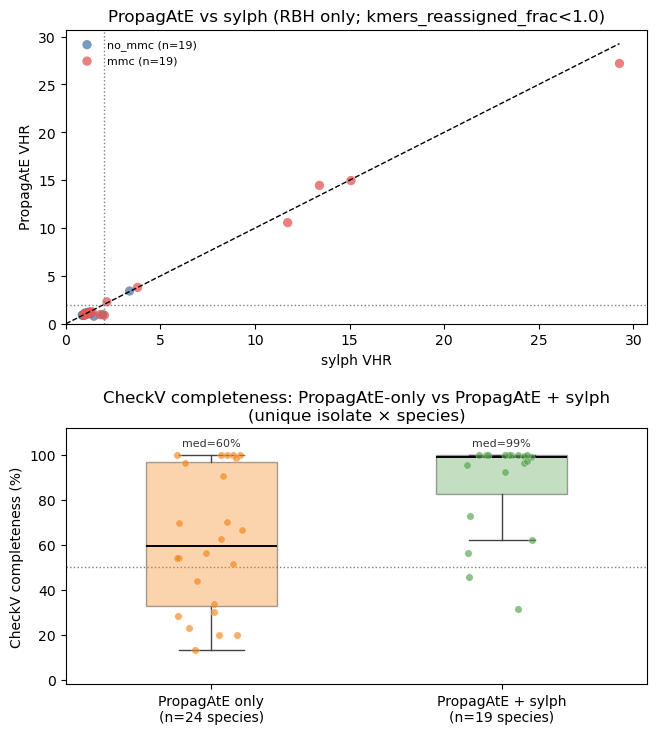

shape: (12, 12)
┌────────────┬────────────┬───────────┬──────────┬───┬─────────┬───────────┬───────────┬───────────┐
│ sample_id_ ┆ mmc_status ┆ point_typ ┆ uhvdb_id ┆ … ┆ match_t ┆ prop_minu ┆ checkv_qu ┆ completen │
│ norm       ┆ ---        ┆ e         ┆ ---      ┆   ┆ ---     ┆ s_sylph   ┆ ality     ┆ ess       │
│ ---        ┆ str        ┆ ---       ┆ str      ┆   ┆ f64     ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆            ┆ str       ┆          ┆   ┆         ┆ f64       ┆ str       ┆ f64       │
╞════════════╪════════════╪═══════════╪══════════╪═══╪═════════╪═══════════╪═══════════╪═══════════╡
│ mvirs_KB18 ┆ mmc        ┆ propagate ┆ null     ┆ … ┆ null    ┆ 2.178063  ┆ High-qual ┆ 90.77     │
│ _mmc       ┆            ┆ _only     ┆          ┆   ┆         ┆           ┆ ity       ┆           │
│ mvirs_YL58 ┆ mmc        ┆ propagate ┆ null     ┆ … ┆ null    ┆ 2.150038  ┆ High-qual ┆ 100.0     │
│ _mmc       ┆            ┆ _only     ┆          ┆   ┆         ┆           

In [15]:
meta_sp = (
    pl.read_csv(METADATA_PATH, separator='\t', columns=['uhvdb_id', 'species_cluster_id', 'species_rep'])
    .with_columns((pl.col('uhvdb_id') == pl.col('species_rep')).alias('is_rep'))
    .sort(['uhvdb_id', 'is_rep'], descending=[False, True])
    .unique(subset=['uhvdb_id'], keep='first')
    .select(['uhvdb_id', 'species_cluster_id'])
)

prop_samples = (
    propagate_raw
    .with_columns(pl.col('sample_id').map_elements(normalize_sample_id, return_dtype=pl.Utf8).alias('sample_id_norm'))
    .select('sample_id_norm')
    .unique()
    .filter(~pl.col('sample_id_norm').str.contains('oligo_fecal'))
)

sylph_vhr_raw = (
    vhr.select([
        'sample_id', 'pair_id', 'mmc_status', 'species_cluster_id', 'Contig_name',
        'host_genus', 'phage_host_ratio',
    ])
    .rename({'phage_host_ratio': 'sylph_phage_host_ratio', 'Contig_name': 'uhvdb_id'})
    .join(
        viruses.select(['sample_id', 'Contig_name', 'ani']).rename({'Contig_name': 'uhvdb_id', 'ani': 'sylph_ani'}),
        on=['sample_id', 'uhvdb_id'],
        how='left',
    )
    .with_columns(pl.col('sample_id').map_elements(normalize_sample_id, return_dtype=pl.Utf8).alias('sample_id_norm'))
    .filter(pl.col('sylph_phage_host_ratio') <= 100)
)
n_sylph_before = sylph_vhr_raw.height
sylph_vhr_raw = sylph_vhr_raw.join(prop_samples, on='sample_id_norm', how='inner')
print(
    f'Restrict to samples with PropagAtE output: {prop_samples.height} samples; '
    f'sylph VHR {n_sylph_before} -> {sylph_vhr_raw.height}'
)

# k-mer conflict filter already applied upstream (kmers_reassigned_frac < KMERS_REASSIGNED_MAX);
# each remaining detection is already its own representative
sylph_vhr = sylph_vhr_raw.unique(subset=['sample_id_norm', 'uhvdb_id'], maintain_order=True)
print(
    f'Sylph VHR after k-mer conflict filter '
    f'(kmers_reassigned_frac<{KMERS_REASSIGNED_MAX}): {sylph_vhr.height} detections'
)
# Per-fragment PropagAtE loci with query_id (exclude oligo fecal)
prop_loci = (
    propagate
    .join(top_hits.select(['sample_id', 'fragment', 'query_id', 'uhvdb_id', 'tani', 'global_ani', 'species_cluster_id']),
          on=['sample_id', 'fragment'], how='inner')
    .with_columns([
        pl.col('sample_id').map_elements(normalize_sample_id, return_dtype=pl.Utf8).alias('sample_id_norm'),
        pl.col('sample_id').map_elements(lambda s: mmc_status_and_pair(s)[0], return_dtype=pl.Utf8).alias('mmc_status'),
    ])
    .rename({'uhvdb_id': 'top_uhvdb', 'tani': 'top_tani', 'global_ani': 'top_gani',
             'species_cluster_id': 'prop_species'})
    .filter(~pl.col('sample_id_norm').str.contains('oligo_fecal'))
)

# --- CheckV completeness for PropagAtE loci (exact fragment id, else coordinate overlap) ---
def _parse_provirus(name: str):
    if name is None or '|provirus_' not in str(name):
        return None
    scaffold, rest = str(name).split('|provirus_', 1)
    parts = rest.split('_')
    try:
        a, b = int(parts[0]), int(parts[1])
    except Exception:
        return None
    return scaffold, min(a, b), max(a, b)


checkv_rows = []
for sample_dir in sorted(GCP_DIR.iterdir()):
    if not sample_dir.is_dir():
        continue
    qs_path = sample_dir / 'checkv' / 'quality_summary.tsv'
    if not qs_path.exists() or qs_path.stat().st_size == 0:
        continue
    try:
        q = pl.read_csv(qs_path, separator='\t', infer_schema_length=10000)
    except Exception:
        continue
    if q.height == 0 or 'contig_id' not in q.columns:
        continue
    sample_norm = normalize_sample_id(sample_dir.name)
    for row in q.iter_rows(named=True):
        parsed = _parse_provirus(row['contig_id'])
        if parsed is None:
            continue
        scaf, a, b = parsed
        comp = row.get('completeness')
        try:
            comp = float(comp) if comp not in (None, 'NA', 'na', '') else None
        except Exception:
            comp = None
        checkv_rows.append({
            'sample_id_norm': sample_norm,
            'contig_id': row['contig_id'],
            'scaffold': scaf,
            'c_start': a,
            'c_stop': b,
            'checkv_quality': row.get('checkv_quality'),
            'completeness': comp,
        })
checkv_iv = pl.DataFrame(checkv_rows) if checkv_rows else pl.DataFrame(
    schema={
        'sample_id_norm': pl.Utf8, 'contig_id': pl.Utf8, 'scaffold': pl.Utf8,
        'c_start': pl.Int64, 'c_stop': pl.Int64, 'checkv_quality': pl.Utf8, 'completeness': pl.Float64,
    }
)

ann_rows = []
for row in prop_loci.iter_rows(named=True):
    exact = checkv_iv.filter(
        (pl.col('sample_id_norm') == row['sample_id_norm'])
        & (pl.col('contig_id') == row['fragment'])
    )
    qual, comp = None, None
    if exact.height:
        qual = exact['checkv_quality'][0]
        comp = exact['completeness'][0]
    else:
        parsed = _parse_provirus(row['fragment'])
        if parsed is not None:
            scaf, a, b = parsed
            cands = checkv_iv.filter(
                (pl.col('sample_id_norm') == row['sample_id_norm']) & (pl.col('scaffold') == scaf)
            )
            best_ov = 0
            for c in cands.iter_rows(named=True):
                ov = max(0, min(b, c['c_stop']) - max(a, c['c_start']) + 1)
                if ov > best_ov:
                    best_ov, qual, comp = ov, c['checkv_quality'], c['completeness']
    ann_rows.append({
        'query_id': row['query_id'],
        'checkv_quality': qual,
        'completeness': float(comp) if comp is not None else None,
    })
prop_loci = prop_loci.join(pl.DataFrame(ann_rows), on='query_id', how='left')
n_comp = prop_loci.filter(pl.col('completeness').is_not_null()).height
print(f'CheckV completeness assigned: {n_comp}/{prop_loci.height} PropagAtE loci')

# ANI hits among in-sample sylph detections; strict RBH per sample
sylph_det = sylph_vhr.select(['sample_id_norm', 'uhvdb_id']).unique()
ani_hits = (
    pl.read_csv(ANICALC_PATH, separator='\t')
    .rename({'qname': 'query_id', 'tname': 'uhvdb_id'})
    .with_columns([
        (pl.col('pid') * pl.col('qcov') / 100).alias('match_q'),
        (pl.col('pid') * pl.col('tcov') / 100).alias('match_t'),
    ])
    .join(prop_loci.select(['query_id', 'sample_id_norm', 'fragment']).unique(), on='query_id', how='inner')
    .join(sylph_det, on=['sample_id_norm', 'uhvdb_id'], how='inner')
    .sort(['sample_id_norm', 'query_id', 'uhvdb_id', 'match_q'], descending=[False, False, False, True])
    .unique(subset=['sample_id_norm', 'query_id', 'uhvdb_id'], maintain_order=True)
)

def build_rbh(hits: pl.DataFrame) -> pl.DataFrame:
    """Strict RBH per sample (figure_s14): reciprocal best by match_q / match_t."""
    rows = []
    if hits.height == 0:
        return pl.DataFrame()
    for sid in hits['sample_id_norm'].unique().to_list():
        links = hits.filter(pl.col('sample_id_norm') == sid)
        best_for_query = links.sort('match_q', descending=True).unique('query_id', maintain_order=True)
        best_for_uhvdb = (
            links.sort('match_t', descending=True)
            .unique('uhvdb_id', maintain_order=True)
            .select(['query_id', 'uhvdb_id'])
        )
        rows.append(best_for_query.join(best_for_uhvdb, on=['query_id', 'uhvdb_id'], how='inner'))
    return pl.concat(rows) if rows else pl.DataFrame()


rbh_links = build_rbh(ani_hits)
print(f'ANI hits (sylph-detected UHVDBs): {ani_hits.height} | RBH pairs: {rbh_links.height}')

both = (
    rbh_links
    .join(
        prop_loci.select([
            'query_id', 'sample_id_norm', 'mmc_status', 'fragment',
            'propagate_phage_host_ratio', 'prop_species', 'top_uhvdb', 'top_tani',
            'checkv_quality', 'completeness',
        ]),
        on=['query_id', 'sample_id_norm'], how='inner',
    )
    .join(
        sylph_vhr.select([
            'sample_id_norm', 'uhvdb_id', 'species_cluster_id', 'sylph_phage_host_ratio',
            'mmc_status', 'host_genus', 'sylph_ani',
        ]),
        on=['sample_id_norm', 'uhvdb_id'], how='inner', suffix='_sylph',
    )
    .with_columns([
        pl.lit('both').alias('point_type'),
        pl.lit('rbh').alias('match_type'),
        pl.coalesce([pl.col('mmc_status'), pl.col('mmc_status_sylph')]).alias('mmc_status'),
        pl.col('species_cluster_id').alias('sylph_species'),
        (pl.col('propagate_phage_host_ratio') - pl.col('sylph_phage_host_ratio')).alias('prop_minus_sylph'),
    ])
)

paired_sylph_keys = both.select(['sample_id_norm', 'uhvdb_id']).unique()
paired_prop_keys = both.select(['query_id']).unique()

sylph_only = (
    sylph_vhr
    .join(paired_sylph_keys, on=['sample_id_norm', 'uhvdb_id'], how='anti')
    .filter(pl.col('sylph_phage_host_ratio') > 0)
    .with_columns([
        pl.lit(0.5).alias('propagate_phage_host_ratio'),
        pl.lit(None).cast(pl.Float64).alias('match_q'),
        pl.lit(None).cast(pl.Float64).alias('match_t'),
        pl.lit('sylph_only').alias('point_type'),
        pl.lit(None).cast(pl.Utf8).alias('match_type'),
        pl.col('species_cluster_id').alias('sylph_species'),
        pl.lit(None).cast(pl.Int64).alias('prop_species'),
        pl.lit(None).cast(pl.Utf8).alias('query_id'),
        (-pl.col('sylph_phage_host_ratio')).alias('prop_minus_sylph'),
    ])
)

prop_only = (
    prop_loci
    .join(paired_prop_keys, on='query_id', how='anti')
    .filter(pl.col('propagate_phage_host_ratio') > 0)
    .with_columns([
        pl.lit(0.5).alias('sylph_phage_host_ratio'),
        pl.lit(None).cast(pl.Float64).alias('match_q'),
        pl.lit(None).cast(pl.Float64).alias('match_t'),
        pl.lit('propagate_only').alias('point_type'),
        pl.lit(None).cast(pl.Utf8).alias('match_type'),
        pl.lit(None).cast(pl.Int64).alias('sylph_species'),
        pl.lit(None).cast(pl.Utf8).alias('uhvdb_id'),
        pl.col('propagate_phage_host_ratio').alias('prop_minus_sylph'),
    ])
)

plot_cols = [
    'sample_id_norm', 'mmc_status', 'point_type', 'match_type', 'query_id', 'uhvdb_id', 'fragment',
    'sylph_phage_host_ratio', 'propagate_phage_host_ratio', 'match_q', 'match_t',
    'sylph_species', 'prop_species', 'prop_minus_sylph', 'checkv_quality', 'completeness',
]
ratio_cmp = pl.concat(
    [df.select([c for c in plot_cols if c in df.columns]) for df in (both, sylph_only, prop_only)],
    how='diagonal_relaxed',
)

n_both = ratio_cmp.filter(pl.col('point_type') == 'both').height
n_sylph_only = ratio_cmp.filter(pl.col('point_type') == 'sylph_only').height
n_prop_only = ratio_cmp.filter(pl.col('point_type') == 'propagate_only').height
print(
    f'PropagAtE <-> sylph VHR (derep): {ratio_cmp.height} '
    f'(both/RBH={n_both}, sylph_only={n_sylph_only}, propagate_only={n_prop_only})'
)
print(ratio_cmp.group_by(['mmc_status', 'point_type']).len().sort(['mmc_status', 'point_type']))

both_pts = ratio_cmp.filter(pl.col('point_type') == 'both')
if both_pts.height >= 3 and spearmanr is not None:
    x = both_pts['sylph_phage_host_ratio'].to_numpy()
    y = both_pts['propagate_phage_host_ratio'].to_numpy()
    rho, p_rho = spearmanr(x, y)
    r, p_r = pearsonr(x, y)
    print(f'RBH both — Spearman ρ={rho:.3f} (p={p_rho:.3g}) | Pearson r={r:.3f} (p={p_r:.3g})')

if ratio_cmp.height:
    fig = plt.figure(figsize=(7.5, 8.5))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.15, 1.0], hspace=0.38)
    ax0 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])

    # Scatter: RBH pairs only, linear axes
    ax = ax0
    mmc_colors = {'no_mmc': '#4C78A8', 'mmc': '#E45756'}
    for status, color in mmc_colors.items():
        sub = both_pts.filter(pl.col('mmc_status') == status)
        if sub.height == 0:
            continue
        ax.scatter(
            sub['sylph_phage_host_ratio'],
            sub['propagate_phage_host_ratio'],
            alpha=0.75, edgecolors='none', c=color, s=45, marker='o',
            label=f'{status} (n={sub.height})',
            zorder=2,
        )
    if both_pts.height:
        lim = max(
            float(both_pts['sylph_phage_host_ratio'].max()),
            float(both_pts['propagate_phage_host_ratio'].max()),
            0.0,
        )
        ax.plot([0, lim], [0, lim], 'k--', lw=1)
        ax.set_xlim(0, lim * 1.05)
        ax.set_ylim(0, lim * 1.05)
    ax.axvline(2, color='gray', ls=':', lw=1)
    ax.axhline(2, color='gray', ls=':', lw=1)
    ax.set(
        xlabel='sylph VHR',
        ylabel='PropagAtE VHR',
        title=f'PropagAtE vs sylph (RBH only; kmers_reassigned_frac<{KMERS_REASSIGNED_MAX})',
    )
    ax.legend(frameon=False, fontsize=8, loc='upper left')

    # Bottom: CheckV completeness — propagate_only vs propagate+sylph (both)
    # Deduplicate MMC/no-MMC: one point per isolate × virus species
    ax = ax2
    comp_df = (
        ratio_cmp
        .filter(
            pl.col('point_type').is_in(['propagate_only', 'both'])
            & pl.col('completeness').is_not_null()
            & pl.col('prop_species').is_not_null()
        )
        .with_columns(
            pl.col('sample_id_norm').str.replace(r'_(mmc|no_mmc)$', '').alias('pair_id')
        )
        .group_by(['point_type', 'pair_id', 'prop_species'])
        .agg(pl.col('completeness').mean().alias('completeness'))
    )
    comp_groups = [
        ('propagate_only', 'PropagAtE only', '#F58518'),
        ('both', 'PropagAtE + sylph', '#54A24B'),
    ]
    box_data, box_labels, box_colors = [], [], []
    for ptype, label, color in comp_groups:
        vals = (
            comp_df
            .filter(pl.col('point_type') == ptype)
            ['completeness']
            .to_numpy()
        )
        box_data.append(vals)
        box_labels.append(f'{label}\n(n={len(vals)} species)')
        box_colors.append(color)
        # jittered points
        if len(vals):
            x = np.full(len(vals), len(box_data) - 1) + np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
            ax.scatter(x, vals, s=28, alpha=0.65, c=color, edgecolors='white', linewidths=0.3, zorder=3)

    bp = ax.boxplot(
        box_data, positions=np.arange(len(box_data)), widths=0.45,
        patch_artist=True, showfliers=False, zorder=2,
        medianprops=dict(color='black', lw=1.4),
        whiskerprops=dict(color='#444444'),
        capprops=dict(color='#444444'),
        boxprops=dict(lw=1.0),
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    # summarize medians
    for i, vals in enumerate(box_data):
        if len(vals):
            med = float(np.median(vals))
            ax.text(i, 103, f'med={med:.0f}%', ha='center', va='bottom', fontsize=8, color='#333333')

    ax.set_xticks(np.arange(len(box_labels)))
    ax.set_xticklabels(box_labels)
    ax.set_ylim(-2, 112)
    ax.set_ylabel('CheckV completeness (%)')
    ax.set_title('CheckV completeness: PropagAtE-only vs PropagAtE + sylph\n(unique isolate × species)')
    ax.axhline(50, color='gray', ls=':', lw=1, zorder=0)

    print(
        comp_df
        .group_by('point_type')
        .agg([
            pl.len().alias('n_species'),
            pl.col('completeness').median().alias('median'),
            pl.col('completeness').mean().alias('mean'),
            pl.col('completeness').quantile(0.25).alias('q25'),
            pl.col('completeness').quantile(0.75).alias('q75'),
        ])
        .sort('point_type')
    )

    plt.show()

    print(ratio_cmp.select([
        'sample_id_norm', 'mmc_status', 'point_type', 'uhvdb_id', 'prop_species', 'sylph_species',
        'sylph_phage_host_ratio', 'propagate_phage_host_ratio', 'match_t', 'prop_minus_sylph',
        'checkv_quality', 'completeness',
    ]).sort('prop_minus_sylph', descending=True).head(12))


## 5. Oligo fecal community: MMC vs no-MMC

Sylph profiles from `results/outputs/referenceanalyze/sylph/profile` and PropagAtE from
`results/genomad_checkv_propagate/mvirs_oligo_fecal_{mmc,no_mmc}/propagate`.

Unlike isolate samples, oligo fecal is a multi-host community. Sylph VHR uses **cascade**
(species → genus singleton → family singleton). Same k-mer conflict filter
(`kmers_reassigned_frac < KMERS_REASSIGNED_MAX`) and VHR ≥ `PHAGE_HOST_RATIO_MIN`.

Paired lines: **Sylph** by `uhvdb_id`; **PropagAtE** by prophage `fragment`. Color = source isolate
(PropagAtE from fragment prefix; sylph by mapping predicted `matched_host_species` / `host_genus` to
isolate GTDB taxonomies from `mvirs_samples.tsv`, species first then unique genus).


Oligo sylph: viruses 42 -> 42 after breadth_ratio>=0.0 and kmers_reassigned_frac<1.0
Oligo sylph VHR (union min): 37 (after VHR>=0.5)
shape: (2, 2)
┌───────────────────┬─────┐
│ host_match_method ┆ len │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ cascade_only      ┆ 4   │
│ min_closest       ┆ 33  │
└───────────────────┴─────┘
Isolate taxonomies (unique species/genus → isolate):
shape: (13, 3)
┌────────────┬────────────────────────────────┬─────────────────────┐
│ isolate_id ┆ ref_species                    ┆ ref_genus           │
│ ---        ┆ ---                            ┆ ---                 │
│ str        ┆ str                            ┆ str                 │
╞════════════╪════════════════════════════════╪═════════════════════╡
│ mvirs_HS   ┆ Escherichia coli               ┆ Escherichia         │
│ mvirs_I46  ┆ Clostridium_AQ innocuum        ┆ Clostridium_AQ      │
│ mvirs_I48  ┆ Bacteroides caecimuris         ┆ Bacteroides         │


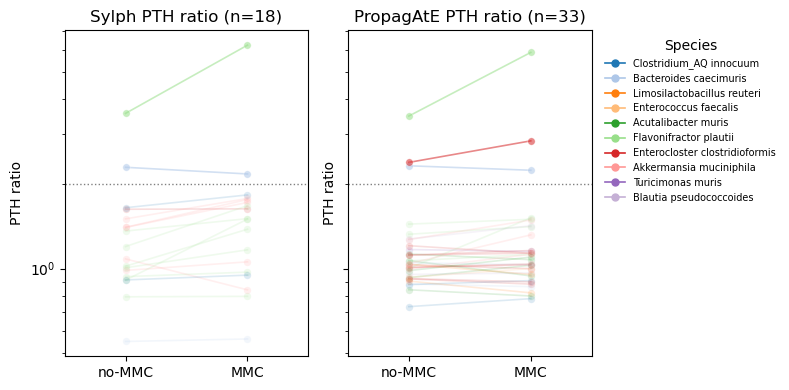

Top oligo sylph fold-changes:
shape: (8, 7)
┌──────────────┬──────────────┬──────────────┬──────────────┬────────────┬──────────┬──────────────┐
│ source_isola ┆ uhvdb_id     ┆ matched_host ┆ host_genus   ┆ vhr_no_mmc ┆ vhr_mmc  ┆ mmc_fold_cha │
│ te           ┆ ---          ┆ _species     ┆ ---          ┆ ---        ┆ ---      ┆ nge          │
│ ---          ┆ str          ┆ ---          ┆ str          ┆ f64        ┆ f64      ┆ ---          │
│ str          ┆              ┆ str          ┆              ┆            ┆          ┆ f64          │
╞══════════════╪══════════════╪══════════════╪══════════════╪════════════╪══════════╪══════════════╡
│ mvirs_YL31   ┆ UHVDB-80607  ┆ Flavonifract ┆ Flavonifract ┆ 3.559984   ┆ 6.220147 ┆ 1.74724      │
│              ┆              ┆ or plautii   ┆ or           ┆            ┆          ┆              │
│ mvirs_YL31   ┆ UHVDB-270674 ┆ Flavonifract ┆ Flavonifract ┆ 0.910121   ┆ 1.499634 ┆ 1.64773      │
│              ┆              ┆ or plautii   ┆ 

In [16]:
OLIGO_SYLPH_DIR = ANALYSIS / 'results/outputs/referenceanalyze/sylph/profile'
OLIGO_COVERM_DIR = ANALYSIS / 'results/outputs/referenceanalyze/coverm/contig'
OLIGO_PROP_SAMPLES = ['mvirs_oligo_fecal_mmc', 'mvirs_oligo_fecal_no_mmc']


def load_oligo_coverm(sample_id: str) -> pl.DataFrame:
    path = OLIGO_COVERM_DIR / sample_id / f'{sample_id}.coverm.tsv.gz'
    return (
        pl.read_csv(
            path, separator='\t', skip_rows=1, has_header=False,
            new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'],
        )
        .with_columns([
            pl.lit(sample_id).alias('sample_id'),
            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
        ])
        .with_columns((1 - np.e ** (-0.833 * pl.col('mean'))).alias('expected_breadth'))
        .with_columns([
            pl.when(pl.col('expected_breadth') > 1e-6)
            .then(pl.col('breadth') / pl.col('expected_breadth'))
            .otherwise(None)
            .alias('breadth_ratio'),
        ])
        .select(['sample_id', 'contig_id', 'breadth', 'breadth_ratio'])
    )


def source_isolate_from_fragment(fragment: str) -> str:
    """mvirs_I48_no_mmc::ACC|provirus_... -> mvirs_I48"""
    prefix = str(fragment).split('::', 1)[0]
    status, pair_id = mmc_status_and_pair(prefix)
    return pair_id if status else prefix


# --- Sylph profiles + CoverM ---
oligo_profile_frames, oligo_empty = [], []
for sample_id in OLIGO_PROP_SAMPLES:
    path = OLIGO_SYLPH_DIR / sample_id / f'{sample_id}.profile.tsv.gz'
    df = pl.read_csv(path, separator='\t')
    if df.height == 0:
        oligo_empty.append(sample_id)
        continue
    status, pair_id = mmc_status_and_pair(sample_id)
    oligo_profile_frames.append(
        df.select([
            pl.lit(sample_id).alias('sample_id'),
            pl.lit(pair_id).alias('pair_id'),
            pl.lit(status).alias('mmc_status'),
            pl.col('Taxonomic_abundance').cast(pl.Float64),
            pl.col('Adjusted_ANI').cast(pl.Float64, strict=False).alias('ani'),
            pl.col('Contig_name').cast(pl.Utf8),
            pl.col('Genome_file').cast(pl.Utf8),
            pl.col('kmers_reassigned').cast(pl.Int64, strict=False),
            pl.col('Containment_ind').cast(pl.Utf8),
        ])
    )

oligo_profiles = pl.concat(oligo_profile_frames).with_columns(
    pl.col('Contig_name').str.starts_with('UHVDB-').alias('is_virus')
)
oligo_virus_raw = oligo_profiles.filter(pl.col('is_virus'))
oligo_bac_rows = oligo_profiles.filter(~pl.col('is_virus'))

oligo_coverm = pl.concat([load_oligo_coverm(s) for s in OLIGO_PROP_SAMPLES])
oligo_detected = (
    oligo_coverm
    .filter(pl.col('breadth_ratio') >= BREADTH_MIN)
    .select(['sample_id', pl.col('contig_id').alias('Contig_name'), 'breadth', 'breadth_ratio'])
)
oligo_virus_rows = (
    oligo_virus_raw
    .with_columns(
        pl.col('Containment_ind').str.split('/').list.get(1).cast(pl.Int64, strict=False).alias('containment_total')
    )
    .with_columns((pl.col('kmers_reassigned') / pl.col('containment_total')).alias('kmers_reassigned_frac'))
    .filter(pl.col('kmers_reassigned_frac').is_null() | (pl.col('kmers_reassigned_frac') < KMERS_REASSIGNED_MAX))
    .join(oligo_detected, on=['sample_id', 'Contig_name'], how='inner')
)
print(
    f'Oligo sylph: viruses {oligo_virus_raw.height} -> {oligo_virus_rows.height} '
    f'after breadth_ratio>={BREADTH_MIN} and kmers_reassigned_frac<{KMERS_REASSIGNED_MAX}'
    + (f' | empty profiles: {oligo_empty}' if oligo_empty else '')
)

oligo_viruses = (
    oligo_virus_rows
    .join(meta, left_on='Contig_name', right_on='uhvdb_id', how='left')
    .join(
        uhvdb_combinedhost.select(['uhvdb_id', 'final_species', 'final_genus', 'final_family']),
        left_on='Contig_name',
        right_on='uhvdb_id',
        how='left',
    )
    .select([
        'sample_id', 'pair_id', 'mmc_status', 'Contig_name',
        'Taxonomic_abundance', 'ani', 'breadth', 'breadth_ratio',
        'species_cluster_id', 'final_species',
        pl.col('final_genus').alias('host_genus'),
        pl.col('final_family').alias('host_family'),
    ])
    .rename({'Taxonomic_abundance': 'virus_tax_abund'})
)

oligo_bac_sylph = (
    oligo_bac_rows
    .with_columns(pl.col('Genome_file').str.extract(r'(GC[AF]_\d+\.\d+)', 1).alias('accession'))
    .join(gtdb_meta, on='accession', how='left')
    .filter(pl.col('species').is_not_null())
    .group_by(['sample_id', 'species', 'genus', 'family'])
    .agg(pl.col('Taxonomic_abundance').max().alias('host_tax_abund'))
)

# Cascade community VHR: species → genus singleton → family singleton
# Cascade: 1) species co-detected 2) genus singleton 3) family singleton
oligo_species_hits = (
    oligo_viruses
    .filter(pl.col('final_species').is_not_null() & (pl.col('virus_tax_abund') > 0))
    .join(
        oligo_bac_sylph.select(['sample_id', 'species', 'host_tax_abund']),
        left_on=['sample_id', 'final_species'],
        right_on=['sample_id', 'species'],
        how='inner',
    )
    .with_columns([
        pl.lit('species_codetected').alias('host_match_method'),
        pl.col('final_species').alias('matched_host_species'),
    ])
)
oligo_matched_keys = oligo_species_hits.select(['sample_id', 'Contig_name']).unique()

oligo_genus_singleton = (
    oligo_bac_sylph
    .group_by(['sample_id', 'genus'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('species').first().alias('species'),
        pl.col('host_tax_abund').first().alias('host_tax_abund'),
    ])
    .filter(pl.col('n_species') == 1)
)
oligo_genus_hits = (
    oligo_viruses
    .join(oligo_matched_keys, on=['sample_id', 'Contig_name'], how='anti')
    .filter(pl.col('host_genus').is_not_null() & (pl.col('virus_tax_abund') > 0))
    .join(
        oligo_genus_singleton.select(['sample_id', 'genus', 'species', 'host_tax_abund']),
        left_on=['sample_id', 'host_genus'],
        right_on=['sample_id', 'genus'],
        how='inner',
    )
    .with_columns([
        pl.lit('genus_singleton').alias('host_match_method'),
        pl.col('species').alias('matched_host_species'),
    ])
)
oligo_matched_keys = pl.concat([
    oligo_matched_keys,
    oligo_genus_hits.select(['sample_id', 'Contig_name']),
]).unique()

oligo_family_singleton = (
    oligo_bac_sylph
    .filter(pl.col('family').is_not_null())
    .group_by(['sample_id', 'family'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('species').first().alias('species'),
        pl.col('host_tax_abund').first().alias('host_tax_abund'),
    ])
    .filter(pl.col('n_species') == 1)
)
oligo_family_hits = (
    oligo_viruses
    .join(oligo_matched_keys, on=['sample_id', 'Contig_name'], how='anti')
    .filter(pl.col('host_family').is_not_null() & (pl.col('virus_tax_abund') > 0))
    .join(
        oligo_family_singleton.select(['sample_id', 'family', 'species', 'host_tax_abund']),
        left_on=['sample_id', 'host_family'],
        right_on=['sample_id', 'family'],
        how='inner',
    )
    .with_columns([
        pl.lit('family_singleton').alias('host_match_method'),
        pl.col('species').alias('matched_host_species'),
    ])
)

oligo_vhr_cols = [
    'sample_id', 'pair_id', 'mmc_status', 'Contig_name', 'species_cluster_id',
    'virus_tax_abund', 'host_tax_abund', 'final_species', 'host_genus', 'host_family',
    'matched_host_species', 'host_match_method',
]
oligo_vhr_cascade = (
    pl.concat([
        oligo_species_hits.select(oligo_vhr_cols),
        oligo_genus_hits.select(oligo_vhr_cols),
        oligo_family_hits.select(oligo_vhr_cols),
    ])
    .with_columns((pl.col('virus_tax_abund') / pl.col('host_tax_abund')).alias('phage_host_ratio'))
    .filter(pl.col('host_tax_abund') > 0)
    .unique(subset=['sample_id', 'Contig_name'], keep='first')
)

# Primary oligo VHR = cascade only
oligo_vhr = (
    oligo_vhr_cascade
    .filter(pl.col('species_cluster_id').is_not_null())
    .sort(['sample_id', 'species_cluster_id', 'virus_tax_abund'], descending=[False, False, True])
    .unique(subset=['sample_id', 'species_cluster_id'], keep='first')
    .filter(pl.col('phage_host_ratio') >= PHAGE_HOST_RATIO_MIN)
)

print(f'Oligo sylph VHR (cascade): {oligo_vhr.height} (after VHR>={PHAGE_HOST_RATIO_MIN})')
print(oligo_vhr.group_by('host_match_method').len().sort('host_match_method'))

# Map predicted host taxonomy -> mvirs isolate via known isolate GTDB species/genus
isolate_tax = (
    ref_host
    .with_columns(
        pl.col('sample_id').map_elements(lambda s: mmc_status_and_pair(s)[1], return_dtype=pl.Utf8)
        .alias('isolate_id')
    )
    .filter(pl.col('ref_species').is_not_null() | pl.col('ref_genus').is_not_null())
    .select(['isolate_id', 'ref_species', 'ref_genus'])
    .unique()
    .sort('isolate_id')
)
# Prefer unique species → isolate; for genus, only when a single isolate has that genus
_sp_n = isolate_tax.filter(pl.col('ref_species').is_not_null()).group_by('ref_species').len()
_gn_n = isolate_tax.filter(pl.col('ref_genus').is_not_null()).group_by('ref_genus').len()
isolate_by_species = (
    isolate_tax
    .join(_sp_n.filter(pl.col('len') == 1).select('ref_species'), on='ref_species', how='inner')
    .select([pl.col('ref_species').alias('matched_host_species'), pl.col('isolate_id').alias('isolate_by_species')])
)
isolate_by_genus = (
    isolate_tax
    .join(_gn_n.filter(pl.col('len') == 1).select('ref_genus'), on='ref_genus', how='inner')
    .select([pl.col('ref_genus').alias('host_genus'), pl.col('isolate_id').alias('isolate_by_genus')])
)
print('Isolate taxonomies (unique species/genus → isolate):')
print(isolate_tax)
print(f'Unique species maps: {isolate_by_species.height} | unique genus maps: {isolate_by_genus.height}')

oligo_sylph_pair = (
    oligo_vhr
    .rename({'Contig_name': 'uhvdb_id', 'phage_host_ratio': 'sylph_phage_host_ratio'})
    .unique(subset=['sample_id', 'uhvdb_id'], maintain_order=True)
    .group_by(['pair_id', 'uhvdb_id'])
    .agg([
        pl.col('sylph_phage_host_ratio').filter(pl.col('mmc_status') == 'no_mmc').first().alias('vhr_no_mmc'),
        pl.col('sylph_phage_host_ratio').filter(pl.col('mmc_status') == 'mmc').first().alias('vhr_mmc'),
        pl.col('matched_host_species').drop_nulls().first().alias('matched_host_species'),
        pl.col('host_genus').drop_nulls().first().alias('host_genus'),
    ])
    .join(isolate_by_species, on='matched_host_species', how='left')
    .join(isolate_by_genus, on='host_genus', how='left')
    .with_columns(
        pl.coalesce([pl.col('isolate_by_species'), pl.col('isolate_by_genus')]).alias('source_isolate')
    )
    .with_columns([
        pl.when(pl.col('vhr_no_mmc').is_not_null() & pl.col('vhr_mmc').is_not_null()).then(pl.lit('both'))
        .when(pl.col('vhr_no_mmc').is_not_null()).then(pl.lit('no_mmc_only'))
        .otherwise(pl.lit('mmc_only'))
        .alias('point_type'),
        pl.coalesce([pl.col('source_isolate'), pl.lit('unmapped')]).alias('color_key'),
    ])
    .with_columns(
        pl.when(pl.col('point_type') == 'both')
        .then(pl.col('vhr_mmc') / pl.col('vhr_no_mmc'))
        .otherwise(None)
        .alias('mmc_fold_change')
    )
)
both_oligo_sylph = oligo_sylph_pair.filter(pl.col('point_type') == 'both')
print(
    'Sylph host→isolate:',
    both_oligo_sylph.group_by('source_isolate').len().sort('len', descending=True)
)

# --- PropagAtE ---
oligo_prop_rows = []
for sample_id in OLIGO_PROP_SAMPLES:
    tsv = GCP_DIR / sample_id / 'propagate' / f'{sample_id}.propagate.tsv'
    df = pl.read_csv(tsv, separator='\t')
    if df.height == 0 or 'prophage' not in df.columns:
        continue
    status, pair_id = mmc_status_and_pair(sample_id)
    oligo_prop_rows.append(
        df.with_columns([
            pl.lit(sample_id).alias('sample_id'),
            pl.lit(status).alias('mmc_status'),
            pl.lit(pair_id).alias('pair_id'),
        ])
        .rename({'prophage': 'fragment', 'prophage-host_ratio': 'propagate_phage_host_ratio'})
        .select([
            'sample_id', 'pair_id', 'mmc_status', 'fragment',
            'propagate_phage_host_ratio', 'prophage_cov_breadth',
        ])
    )
oligo_prop = (
    pl.concat(oligo_prop_rows)
    .filter(pl.col('prophage_cov_breadth') >= 0.5)
    .with_columns(
        pl.col('fragment').map_elements(source_isolate_from_fragment, return_dtype=pl.Utf8).alias('source_isolate')
    )
)
oligo_prop_pair = (
    oligo_prop
    .group_by(['pair_id', 'fragment'])
    .agg([
        pl.col('propagate_phage_host_ratio').filter(pl.col('mmc_status') == 'no_mmc').first().alias('vhr_no_mmc'),
        pl.col('propagate_phage_host_ratio').filter(pl.col('mmc_status') == 'mmc').first().alias('vhr_mmc'),
        pl.col('source_isolate').first().alias('source_isolate'),
    ])
    .with_columns([
        pl.when(pl.col('vhr_no_mmc').is_not_null() & pl.col('vhr_mmc').is_not_null()).then(pl.lit('both'))
        .when(pl.col('vhr_no_mmc').is_not_null()).then(pl.lit('no_mmc_only'))
        .otherwise(pl.lit('mmc_only'))
        .alias('point_type'),
        pl.col('source_isolate').alias('color_key'),
    ])
    .with_columns(
        pl.when(pl.col('point_type') == 'both')
        .then(pl.col('vhr_mmc') / pl.col('vhr_no_mmc'))
        .otherwise(None)
        .alias('mmc_fold_change')
    )
)
both_oligo_prop = oligo_prop_pair.filter(pl.col('point_type') == 'both')

print('Oligo sylph pairing:', oligo_sylph_pair['point_type'].value_counts())
print(f'Oligo sylph paired: {both_oligo_sylph.height}')
print('Oligo PropagAtE pairing:', oligo_prop_pair['point_type'].value_counts())
print(
    f'Oligo PropagAtE paired loci: {both_oligo_prop.height} across '
    f'{both_oligo_prop["source_isolate"].n_unique()} source isolates'
)


def paired_mmc_colored(ax, paired_df, title, ylabel, color_map):
    if paired_df.height == 0:
        ax.set_title(title + ' (none)')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['no-MMC', 'MMC'])
        return
    rng = np.random.default_rng(0)
    for row in paired_df.iter_rows(named=True):
        color = color_map.get(row['color_key'], '0.4')
        j = float(rng.uniform(-0.00, 0.00))
        xs = [0 + j, 1 + j]
        ys = [row['vhr_no_mmc'], row['vhr_mmc']]
        crosses_vhr2 = max(ys) >= 2
        alpha = 0.55 if crosses_vhr2 else 0.15
        z = 3 if crosses_vhr2 else 1
        ax.plot(xs, ys, color=color, alpha=alpha, lw=1.2, zorder=z)
        ax.scatter(xs, ys, color=color, s=28, alpha=alpha, zorder=z + 1,
                   edgecolors='white', linewidths=0.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['no-MMC', 'MMC'])
    ax.set_xlim(-0.5, 1.5)
    ax.set_yscale('log')
    ax.axhline(2, color='gray', ls=':', lw=1, zorder=0)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} (n={paired_df.height})')


sylph_keys = sorted(both_oligo_sylph['color_key'].drop_nulls().unique().to_list())
prop_keys = sorted(both_oligo_prop['color_key'].drop_nulls().unique().to_list())
isolate_keys = sorted(set(sylph_keys) | set(prop_keys), key=lambda k: (k == 'unmapped', k))
cmap = plt.get_cmap('tab20')
oligo_isolate_colors = {
    k: ('0.55' if k == 'unmapped' else cmap(i % 20))
    for i, k in enumerate(isolate_keys)
}

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
paired_mmc_colored(axes[0], both_oligo_sylph, 'Sylph PTH ratio', 'PTH ratio', oligo_isolate_colors)
paired_mmc_colored(axes[1], both_oligo_prop, 'PropagAtE PTH ratio', 'PTH ratio', oligo_isolate_colors)

isolate_species_map = dict(
    isolate_tax
    .select(['isolate_id', 'ref_species'])
    .iter_rows()
)
handles = [
    plt.Line2D(
        [0], [0], color=oligo_isolate_colors[k], marker='o', lw=1.2, markersize=5,
        label=(
            'unmapped' if k == 'unmapped'
            else (isolate_species_map.get(k) or k.replace('mvirs_', ''))
        ),
    )
    for k in isolate_keys
]
axes[1].legend(
    handles=handles, frameon=False, fontsize=7, title='Species',
    loc='upper left', bbox_to_anchor=(1.02, 1.0),
)
fig.tight_layout()
plt.show()

print('Top oligo sylph fold-changes:')
print(
    both_oligo_sylph
    .select([
        'source_isolate', 'uhvdb_id', 'matched_host_species', 'host_genus',
        'vhr_no_mmc', 'vhr_mmc', 'mmc_fold_change',
    ])
    .sort('mmc_fold_change', descending=True)
    .head(8)
)
print('Top oligo PropagAtE fold-changes:')
print(
    both_oligo_prop
    .select(['source_isolate', 'fragment', 'vhr_no_mmc', 'vhr_mmc', 'mmc_fold_change'])
    .sort('mmc_fold_change', descending=True)
    .head(8)
)
